## IMPORTS

In [70]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json
import plotly.graph_objects as go
import seaborn as sns

from scipy.stats import pearsonr
from matplotlib.patches import Patch
from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

MARKOV_STEPS = 1000
DESIRED_TCP = 0.8

## RED/GREEN BOXPLOTS

In [71]:
'''
neutral_df = pd.read_csv("csvs/colorado_cog_neutral_250k.csv")
#optimized_df = pd.read_csv("data/missouri_optimized_500k.csv")
#unoptimized_df = pd.read_csv("data/missouri_unoptimized_500k.csv")

# take top and bottom 20% of maps
top_20_cutoff = neutral_df['tcp_score'].quantile(0.80)
bottom_20_cutoff = neutral_df['tcp_score'].quantile(0.20)

high_tcp_maps = neutral_df[neutral_df['tcp_score'] >= top_20_cutoff]
low_tcp_maps = neutral_df[neutral_df['tcp_score'] <= bottom_20_cutoff]

# unpack data - lists for each district
share_cols = [f'dist_{i}_dem_share' for i in range(1, 9)]
data_high = [high_tcp_maps[col] for col in share_cols]
data_low = [low_tcp_maps[col] for col in share_cols]


fig, ax = plt.subplots(figsize=(14, 7))

# offset
pos_low = np.arange(1, 9) - 0.15
pos_high = np.arange(1, 9) + 0.15

# low tcp box
bp_low = ax.boxplot(data_low, positions=pos_low, widths=0.25, patch_artist=True, 
                    boxprops=dict(facecolor="lightcoral", color="black"),
                    medianprops=dict(color="black", linewidth=1.5))

# high tcp box
bp_high = ax.boxplot(data_high, positions=pos_high, widths=0.25, patch_artist=True, 
                    boxprops=dict(facecolor="lightgreen", color="black"),
                    medianprops=dict(color="black", linewidth=1.5))

# Formatting
ax.axhline(0.5, color='red', linestyle='dashed', linewidth=2, label='50% Win Threshold')
ax.set_xticks(range(1, 9))
ax.set_xticklabels([f"Dist {i}" for i in range(1, 9)])
ax.set_title("How Preserving Communities Shifts the Vote Share", fontsize=16)
ax.set_xlabel("District (Ranked Most Republican to Most Democratic)")
ax.set_ylabel("Democratic Vote Share")

# legend
legend_elements = [
    Patch(facecolor='lightcoral', edgecolor='black', label='Low TCP Maps (Worst 20%)'),
    Patch(facecolor='lightgreen', edgecolor='black', label='High TCP Maps (Best 20%)'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.show()
'''

'\nneutral_df = pd.read_csv("csvs/colorado_cog_neutral_250k.csv")\n#optimized_df = pd.read_csv("data/missouri_optimized_500k.csv")\n#unoptimized_df = pd.read_csv("data/missouri_unoptimized_500k.csv")\n\n# take top and bottom 20% of maps\ntop_20_cutoff = neutral_df[\'tcp_score\'].quantile(0.80)\nbottom_20_cutoff = neutral_df[\'tcp_score\'].quantile(0.20)\n\nhigh_tcp_maps = neutral_df[neutral_df[\'tcp_score\'] >= top_20_cutoff]\nlow_tcp_maps = neutral_df[neutral_df[\'tcp_score\'] <= bottom_20_cutoff]\n\n# unpack data - lists for each district\nshare_cols = [f\'dist_{i}_dem_share\' for i in range(1, 9)]\ndata_high = [high_tcp_maps[col] for col in share_cols]\ndata_low = [low_tcp_maps[col] for col in share_cols]\n\n\nfig, ax = plt.subplots(figsize=(14, 7))\n\n# offset\npos_low = np.arange(1, 9) - 0.15\npos_high = np.arange(1, 9) + 0.15\n\n# low tcp box\nbp_low = ax.boxplot(data_low, positions=pos_low, widths=0.25, patch_artist=True, \n                    boxprops=dict(facecolor="lightcoral

## READING FILES

In [72]:
#updated vtds from census blocks
vtds = gpd.read_file("data/co.shp")
#from representable (338 COIS)
cois = gpd.read_file("data/Colorado_communities.geojson")
#congressional map
congressional_2021 = gpd.read_file("data/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_w_Final_Adjustments.shp")

Skipping field block_group_ids: unsupported OGR type: 5
Skipping field census_block_ids: unsupported OGR type: 5


## PLOTTING

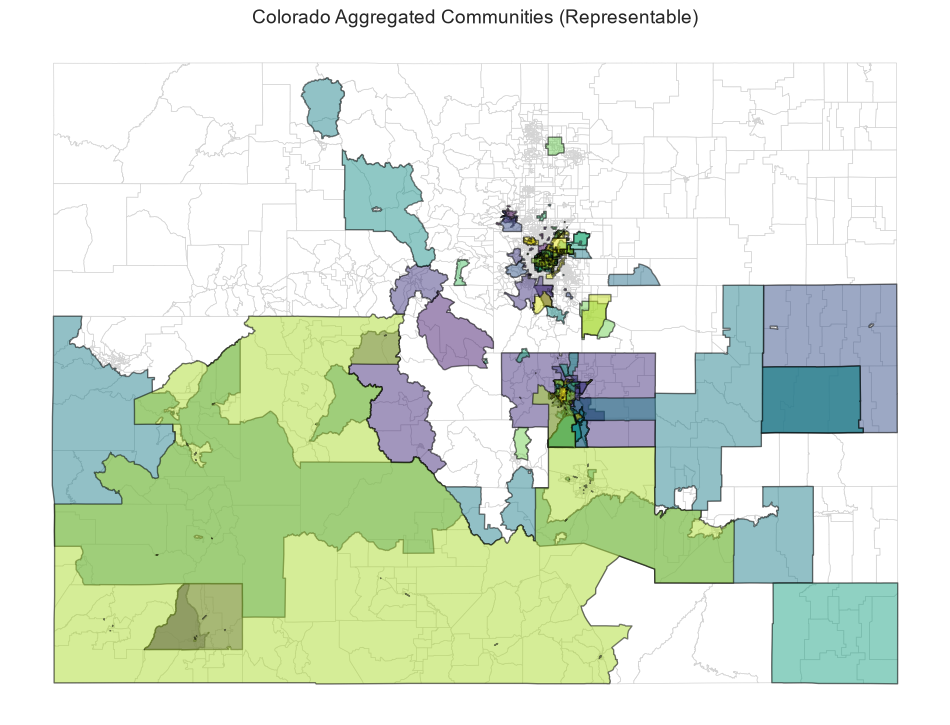

"\ncois['shape_size'] = cois.area\ncois_sorted = cois.sort_values(by='shape_size', ascending = False)\n\nfor i in len(cois_sorted):\n\n    single_coi = cois_sorted.iloc[[i]]\n    fig, ax = plt.subplots(figsize=(8, 8))\n\n    single_coi.plot(ax=ax, facecolor='skyblue', edgecolor='black')\n    plt.title(single_coi.entry_name)\n\nplt.show()\n"

In [73]:
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)
    
fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightgray", linewidth=0.5)
cois.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")

ax.set_title("Colorado Aggregated Communities (Representable)", fontsize=14)
ax.axis("off")
plt.show()

#if you ever wanted to print individual cois by area
'''
cois['shape_size'] = cois.area
cois_sorted = cois.sort_values(by='shape_size', ascending = False)

for i in len(cois_sorted):

    single_coi = cois_sorted.iloc[[i]]
    fig, ax = plt.subplots(figsize=(8, 8))

    single_coi.plot(ax=ax, facecolor='skyblue', edgecolor='black')
    plt.title(single_coi.entry_name)

plt.show()
'''

In [74]:
#if cois.crs != vtds.crs:
    #vtds = vtds.to_crs(cois.crs)

vtds['TOTVOTES20'] = vtds['PRE20D'] + vtds['PRE20R'] + vtds['PRE20O']


vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

clean_overlaps['coi_pop'] = clean_overlaps['TOTVOTES20'] * clean_overlaps['coi_fraction']

coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME20']
    cluster_id = row['entry_ID']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk


vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME20']]

C:\Users\noede\AppData\Local\Temp\ipykernel_19320\2432568374.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vtds['vtd_area'] = vtds.geometry.area
C:\Users\noede\AppData\Local\Temp\ipykernel_19320\2432568374.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']


## 2021 CO Congressional Map Cleanup

In [75]:
congressional_2021 = congressional_2021.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2021 = gpd.sjoin(vtd_points, congressional_2021, how="left", predicate="intersects")

vtds['district_2021'] = joined_vtds_2021['District']

## DEUBGGING

In [76]:
#print("hello world")

## HELPER FUNCTIONS

In [77]:
def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)

def plot_partition(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vtds.plot(ax=ax, column="district", cmap='Pastel1',edgecolor="black", linewidth=0.15)
    #cois.plot(ax=ax, column="cluster", facecolor='none', edgecolor="red", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

def plot_partition_party(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    district_colors = {}
    most_dem_val = 0
    most_dem_district = None
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            dem_pop += partition.graph.nodes[node_id]['PRE20D']
            tot_pop += partition.graph.nodes[node_id]['TOTVOTES20']
            
        if tot_pop > 0 and (dem_pop / tot_pop) > 0.5:
            district_colors[district_id] = "lightblue"
            if dem_pop/tot_pop > most_dem_val:
                most_dem_val = dem_pop/tot_pop
                district_colors[most_dem_district] = 'lightblue'
                district_colors[district_id] = "darkblue"
                most_dem_district = district_id
        else:
            district_colors[district_id] = "lightcoral"
            
    
    vtds['party_color'] = vtds['district'].map(district_colors)
    
    fig, ax = plt.subplots(figsize=(12, 10))

    partition.plot(ax=ax, edgecolor = "black", linewidth = 2)
    vtds.plot(ax=ax, color=vtds['party_color'], edgecolor="black", linewidth=0.15)
    print(most_dem_val)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

    partition.plot(ax=ax, edgecolor = "black", linewidth = 2)
    vtds.plot(ax=ax, color=vtds['party_color'], edgecolor="black", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

def plot_detailed(vtds_gdf, cois_gdf, community_scores_df, district_col, title="Community Map"):
        """
        generates an interactive Plotly map mapping COI preservation (SSS scores) 
        under a specific district plan.
        
        Parameters:
        - vtds_gdf: GeoDataFrame containing the base precincts/VTDs
        - cois_gdf: GeoDataFrame containing the community shapes
        - community_scores_df: DataFrame output from score_communities()
        - district_col: String name of the column in vtds_gdf representing the districts
        - title: String title for the plot
        """
        
        # set coords for plotly
        vtds_4326 = vtds_gdf.to_crs(epsg=4326)
        cois_4326 = cois_gdf.to_crs(epsg=4326)
        
        # get district lines
        vtds_4326.geometry = vtds_4326.geometry.make_valid()
        districts_4326 = vtds_4326.dissolve(by=district_col).reset_index()
        
        # merge metrics into coi map
        cois_enriched = cois_4326.merge(
            community_scores_df[['community_id', 'sss_score', 'total_pop']], 
            left_on='entry_ID', 
            right_on='community_id', 
            how='left'
        )
        cois_enriched['sss_score'] = cois_enriched['sss_score'].fillna(0)
        cois_enriched['total_pop'] = cois_enriched['total_pop'].fillna(0)
        
        # convert to json for plotly
        cois_geojson = json.loads(cois_enriched.to_json())
        districts_geojson = json.loads(districts_4326.to_json())
        
        # init plotly
        fig = go.Figure()
        
        # COI overlay - colored by SSS score
        fig.add_trace(
            go.Choroplethmap(
                geojson=cois_geojson,
                locations=cois_enriched.index,
                z=cois_enriched["sss_score"],  
                text=cois_enriched["entry_ID"],  
                customdata=cois_enriched[["total_pop", "sss_score"]], 
                colorscale="RdYlGn", # Red = Fractured, Green = Preserved
                zmin=0.0, zmax=1.0,  # Lock the scale so 1.0 is always max green
                showscale=True,
                colorbar_title="SSS Score",
                marker=dict(opacity=0.7, line=dict(width=0.5, color="black")),
                hovertemplate=(
                    "<b>Cluster ID:</b> %{text}<br>"
                    "<b>Total Population:</b> %{customdata[0]:,.0f}<br>"
                    "<b>SSS Score:</b> %{customdata[1]:.4f}<extra></extra>"
                ),
            )
        )
        
        # Districts overlay
        fig.add_trace(
            go.Choroplethmap(
                geojson=districts_geojson,
                locations=districts_4326.index,
                z=[1] * len(districts_4326),
                colorscale=[[0, "rgba(0,0,0,0)"], [1, "rgba(0,0,0,0)"]],
                showscale=False,
                marker=dict(line=dict(width=2.5, color="black")),
                hoverinfo="skip",
            )
        )
        
        # center cam
        minx, miny, maxx, maxy = vtds_4326.total_bounds
        center_lat = (miny + maxy) / 2
        center_lon = (minx + maxx) / 2
        
        fig.update_layout(
            title=title,
            map_style="open-street-map",
            map_zoom=6,
            map_center={"lat": center_lat, "lon": center_lon},
            margin={"r": 0, "t": 40, "l": 0, "b": 0},
            height=800,
        )
        
        fig.show()


## SCORING FUNCTIONS

In [78]:
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1

    return dem_wins

def dem_share(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
            
        dem_share = dem_pop / tot_pop if tot_pop > 0 else 0
        dem_shares.append(dem_share)
        
    dem_shares.sort()
    return tuple(dem_shares)

def dem_boxes(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        dem_share = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['PRE20D']
            tot_pop += node_attrs['TOTVOTES20']
        dem_share = dem_pop / tot_pop
        dem_shares.append(dem_share)
    dem_shares.sort()
    return dem_shares

def communities_split(partition):
    df = extract_data(partition)
    ss_scores = score_communities(df)
    communities_split = (ss_scores['sss_score'] != 1).sum()
    return communities_split
    
def square_root_entropy(partition):
     
     raw_df = extract_data(partition)

     total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
     total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

     district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()
     merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

     merged['share'] = merged['pop'] / merged['total_pop']

     merged['sre_score'] = np.sqrt(merged['share'])

     final_sre_df = merged.groupby(['category', 'community_id', 'total_pop'])['sre_score'].sum().reset_index()

     final_sre = final_sre_df['sre_score'].sum()

     return(final_sre)

def shannon_entropy(partition):
     
     raw_df = extract_data(partition)

     total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
     total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

     district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()
     merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

     merged['share'] = merged['pop'] / merged['total_pop']
     merged['share_inv'] = merged['total_pop'] / merged['pop']

     merged['se_score'] = merged['share'] * np.log2(merged['share_inv'])

     final_se_df = merged.groupby(['category', 'community_id', 'total_pop'])['se_score'].sum().reset_index()

     final_se = final_se_df['se_score'].sum()

     return(final_se)

def even_splits(partition):
     
     raw_df = extract_data(partition)

     total_pops = raw_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
     total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

     district_splits = raw_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()
     merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])
     #muni_merged = merged[merged['category'] == 'county']

     #print(muni_merged['community_id'].unique())
     es_score = 0

     for c_id in merged['community_id'].unique():
         muni_simp = merged[merged['community_id'] ==  c_id]
         splits = len(muni_simp)
         min = muni_simp['pop'].min()
         total_pop = muni_simp['pop'].sum()
         min = min/total_pop
         es = splits * (1-min)
      
         es_score += es

     #print(es_score)
     return es_score
    

## INIT GRAPH AND CHAIN

In [79]:
from gerrychain.accept import always_accept
## init graph
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# Colorado has 35 state senate districts
total_population = sum(node.get('TOTVOTES20', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTVOTES20", 
    epsilon=0.05
)

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'dem_share': dem_share,
        'dem_box': dem_boxes,
        'communities_split': communities_split,
        'sre': square_root_entropy,
        'se': shannon_entropy,
        'es': even_splits
    }
)

## init chain
proposal = partial(recom, pop_col="TOTVOTES20", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

c:\Users\noede\OneDrive\Desktop\CS\MCURE\coi-preservation-project\.venv\Lib\site-packages\gerrychain\graph\graph.py:266: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = df.geometry.area.to_dict()


In [80]:
shannon_entropy(initial_partition)

np.float64(70.14632728788871)

## RUN CHAIN

In [81]:
# collect scores
tcp_scores = []
cut_edges_count = []
dem_wins_count = []
dem_boxes = []
communities_split_list = []
sre_scores = []
se_scores = []
es_scores = []

# dem shares init
dist_1_shares = []
dist_2_shares = []
dist_3_shares = []
dist_4_shares = []
dist_5_shares = []
dist_6_shares = []
dist_7_shares = []
dist_8_shares = []


# maps score
best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

# all tcp scores grouped by seat count
tcp_scores_by_seats = {seat_count: [] for seat_count in range(9)}

for partition in chain:
    # track every 50k steps
    if len(tcp_scores) > 0 and len(tcp_scores) % 50000 == 0:
        print(f"completed {len(tcp_scores)} steps...")

    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']
    shares = partition['dem_share']
    boxes = partition['dem_box']
    c_split = partition['communities_split']
    sre = partition['sre']
    se = partition['se']
    es = partition['es']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)
    dem_boxes.append(boxes)
    communities_split_list.append(c_split)
    sre_scores.append(sre)
    se_scores.append(se)
    es_scores.append(es)

    dist_1_shares.append(shares[0])
    dist_2_shares.append(shares[1])
    dist_3_shares.append(shares[2])
    dist_4_shares.append(shares[3])
    dist_5_shares.append(shares[4])
    dist_6_shares.append(shares[5])
    dist_7_shares.append(shares[6])
    dist_8_shares.append(shares[7])
    

    # append scores under its seat count 
    tcp_scores_by_seats[seats].append(score)

    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition

    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

# save to csv
chain_results = {
    'step': range(len(tcp_scores)),
    'tcp_score': tcp_scores,
    'cut_edges': cut_edges_count,
    'dem_wins': dem_wins_count,
    'communities_split': communities_split_list,
    'sre': sre_scores,
    'se': se_scores,
    'es': es_scores,
    'dist_1_dem_share': dist_1_shares,
    'dist_2_dem_share': dist_2_shares,
    'dist_3_dem_share': dist_3_shares,
    'dist_4_dem_share': dist_4_shares,
    'dist_5_dem_share': dist_5_shares,
    'dist_6_dem_share': dist_6_shares,
    'dist_7_dem_share': dist_7_shares,
    'dist_8_dem_share': dist_8_shares
}


In [82]:
#results_df = pd.DataFrame(chain_results)
#results_df.to_csv("csvs/colorado_cog_neutral_250k.csv", index=False)

[[0.38584171289662106, 0.47437554920359165, 0.4923361856757707, 0.5019845294348911, 0.5604572061788501, 0.5920478718213931, 0.6478211040000391, 0.7698729799033932], [0.4375826862237561, 0.44958374256315853, 0.47437554920359165, 0.4923361856757707, 0.5604572061788501, 0.5920478718213931, 0.6478211040000391, 0.7698729799033932], [0.44199808883520814, 0.44958374256315853, 0.46938302149373745, 0.4923361856757707, 0.5604572061788501, 0.5920478718213931, 0.6478211040000391, 0.7698729799033932], [0.44199808883520814, 0.46938302149373745, 0.4923361856757707, 0.5078130700044028, 0.537415762528183, 0.5604572061788501, 0.6478211040000391, 0.7698729799033932], [0.44199808883520814, 0.46938302149373745, 0.4923361856757707, 0.5078130700044028, 0.537415762528183, 0.5604572061788501, 0.704225790539861, 0.7150309137821917], [0.4407404924865881, 0.4699833112034206, 0.4923361856757707, 0.5078130700044028, 0.537415762528183, 0.5604572061788501, 0.704225790539861, 0.7150309137821917], [0.4407404924865881, 

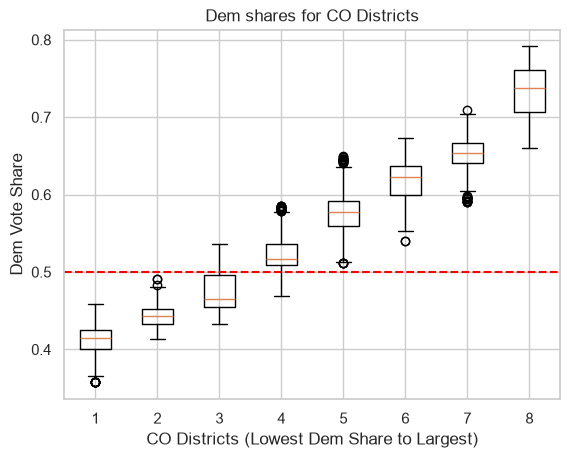

In [83]:

print(dem_boxes)
grouped_data = list(zip(*dem_boxes))

plt.boxplot(grouped_data, label= ['1', '2', '3', '4', '5', '6', '7', '8'])
plt.axhline(0.5, color="red", linestyle="dashed", label="50% line")

# Add titles and labels for clarity
plt.title("Dem shares for CO Districts")
plt.xlabel("CO Districts (Lowest Dem Share to Largest)")
plt.ylabel("Dem Vote Share")
# Display the plot
plt.show()


## ENACTED PARTITION

In [84]:
enacted_2021 = Partition(
    g,
    assignment="district_2021",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'communities_split': communities_split
    }
)

## HISTOGRAMS

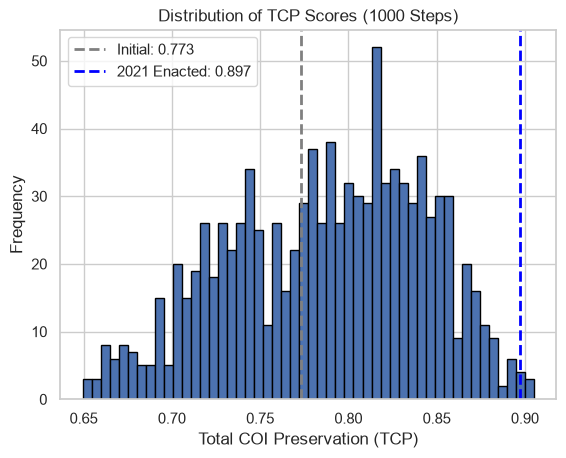

In [85]:
# hist: tcp scores distribution
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
score_2021 = enacted_2021["tcp_score"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


#average_tcp = sum(tcp_scores)/len(tcp_scores)
#print(average_tcp)

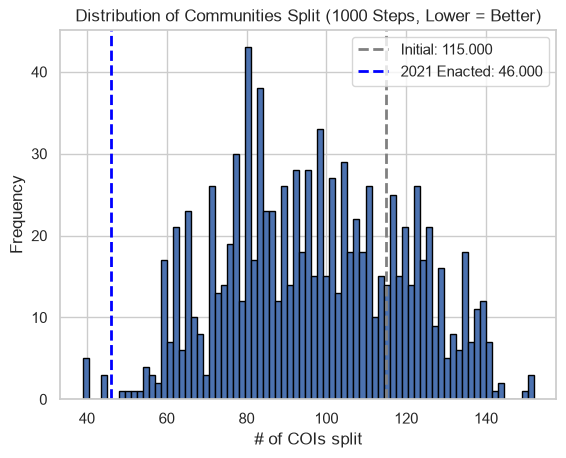

In [86]:
plt.hist(communities_split_list, bins=75, edgecolor="black")
initial_score = initial_partition["communities_split"]
score_2021 = enacted_2021["communities_split"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of Communities Split ({MARKOV_STEPS} Steps, Lower = Better)")
plt.xlabel("# of COIs split")
plt.ylabel("Frequency")
plt.legend()
plt.show()


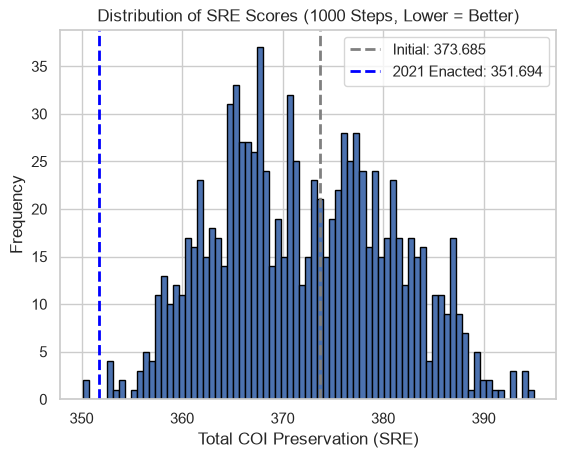

In [87]:
plt.hist(sre_scores, bins=75, edgecolor="black")
initial_score = initial_partition["sre"]
score_2021 = enacted_2021["sre"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of SRE Scores ({MARKOV_STEPS} Steps, Lower = Better)")
plt.xlabel("Total COI Preservation (SRE)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

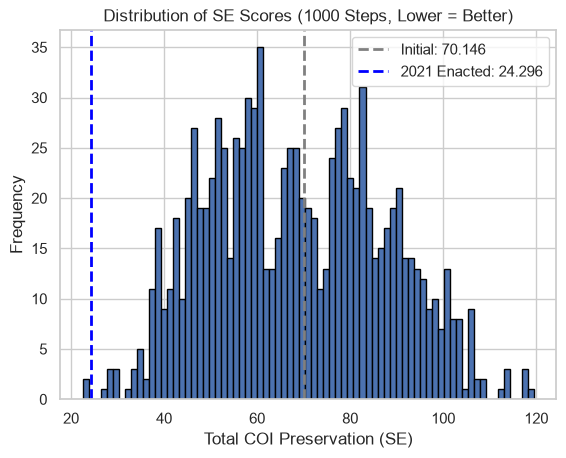

In [88]:
plt.hist(se_scores, bins=75, edgecolor="black")
initial_score = initial_partition["se"]
score_2021 = enacted_2021["se"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of SE Scores ({MARKOV_STEPS} Steps, Lower = Better)")
plt.xlabel("Total COI Preservation (SE)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

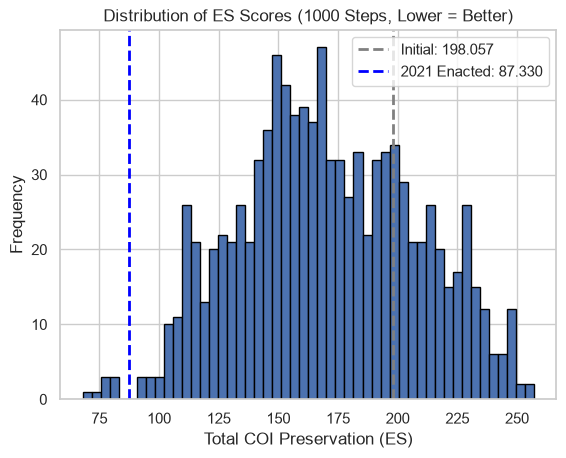

In [89]:
plt.hist(es_scores, bins=50, edgecolor="black")
initial_score = initial_partition["es"]
score_2021 = enacted_2021["es"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2021 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of ES Scores ({MARKOV_STEPS} Steps, Lower = Better)")
plt.xlabel("Total COI Preservation (ES)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

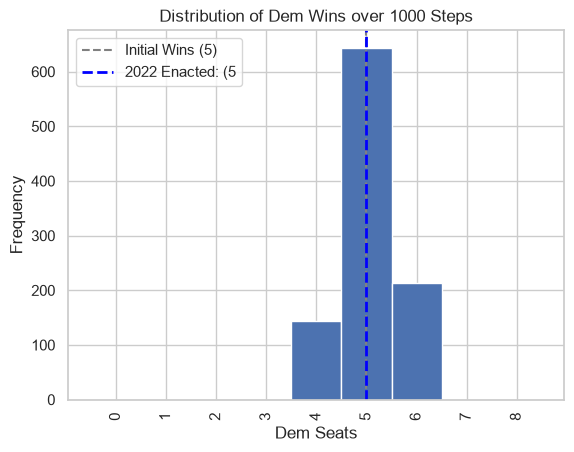

In [90]:
# hist: dem seats distribution
n_districts = len(initial_partition.parts)
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
wins_2021 = count_dem_wins(enacted_2021)

plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')

plt.axvline(
    x = wins_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: ({wins_2021}",
)

plt.xticks(rotation = 'vertical')
plt.legend()
plt.show()

[4, 5, 6]


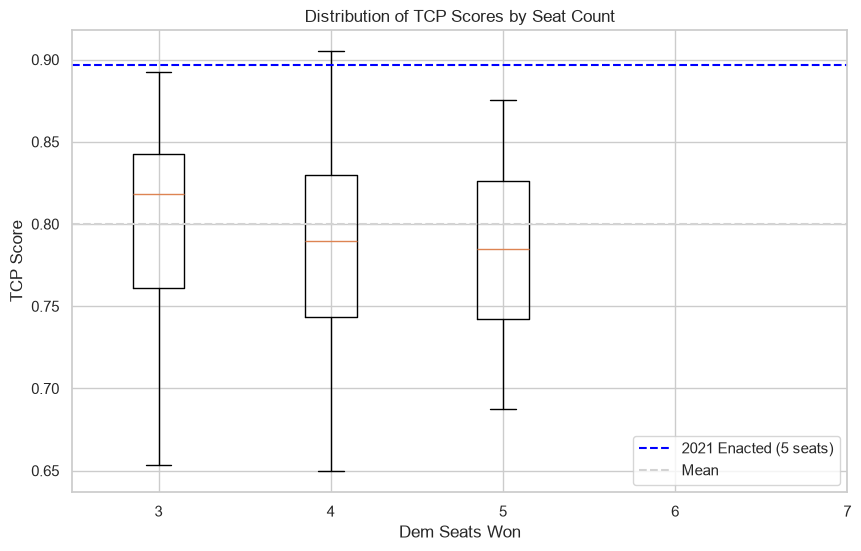

In [91]:
seats_with_data = [s for s in range(9) if len(tcp_scores_by_seats[s]) > 0]
data_to_plot = [tcp_scores_by_seats[s] for s in seats_with_data]
score_2021 = enacted_2021["tcp_score"]
print(seats_with_data)

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot)
plt.axhline(score_2021, color="blue", linestyle="dashed", label=f"2021 Enacted ({wins_2021} seats)")
plt.axhline(DESIRED_TCP, color="lightgrey", linestyle="dashed", label="Mean")
plt.xlabel("Dem Seats Won")
plt.ylabel("TCP Score")
plt.xticks([1,2,3,4,5], [3,4,5,6,7])
plt.title("Distribution of TCP Scores by Seat Count")
plt.legend()
plt.show()

## CORRELATION SCATTER PLOTS

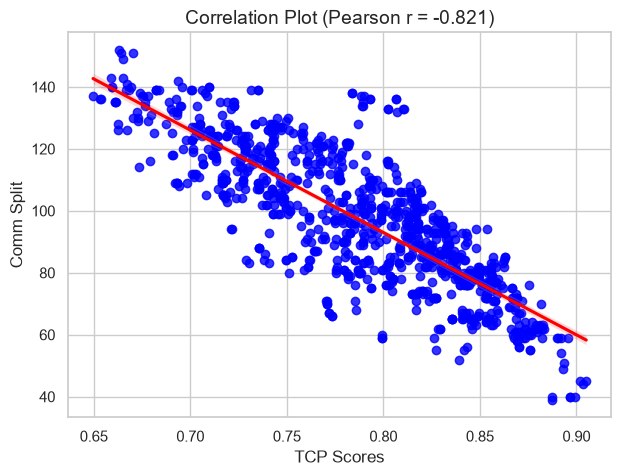

In [92]:
corr_coef, p_value = pearsonr(tcp_scores, communities_split_list)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

sns.regplot(x=tcp_scores, y=communities_split_list, scatter_kws={"color": "blue"}, line_kws={"color": "red"}, marker="o")

plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
plt.xlabel("TCP Scores")
plt.ylabel("Comm Split")

plt.show()

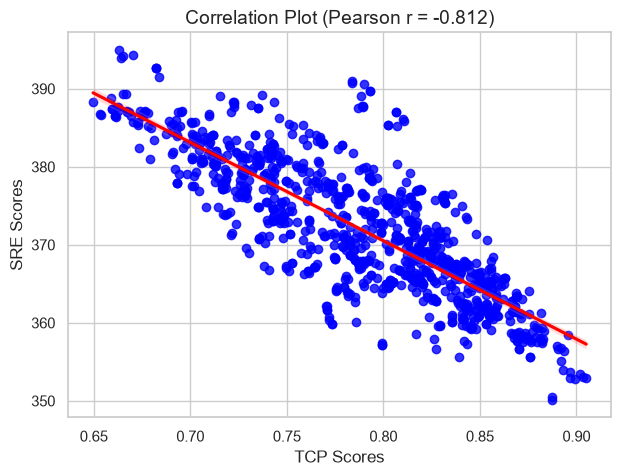

In [93]:
corr_coef, p_value = pearsonr(tcp_scores, sre_scores)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

sns.regplot(x=tcp_scores, y=sre_scores, scatter_kws={"color": "blue"}, line_kws={"color": "red"}, marker="o")

plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
plt.xlabel("TCP Scores")
plt.ylabel("SRE Scores")

plt.show()

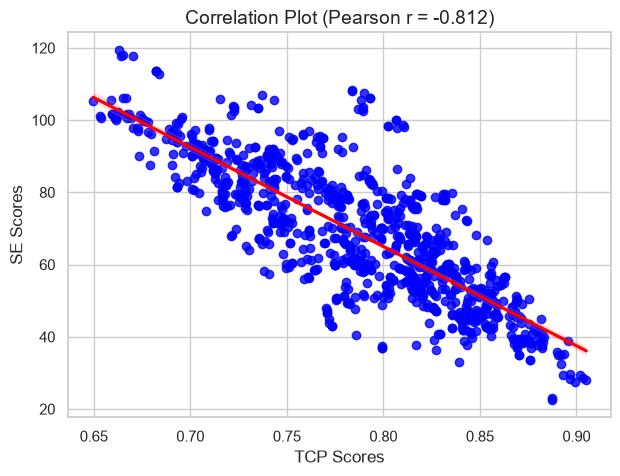

In [94]:
corr_coef, p_value = pearsonr(tcp_scores, se_scores)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

sns.regplot(x=tcp_scores, y=se_scores, scatter_kws={"color": "blue"}, line_kws={"color": "red"}, marker="o")

plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
plt.xlabel("TCP Scores")
plt.ylabel("SE Scores")

plt.show()

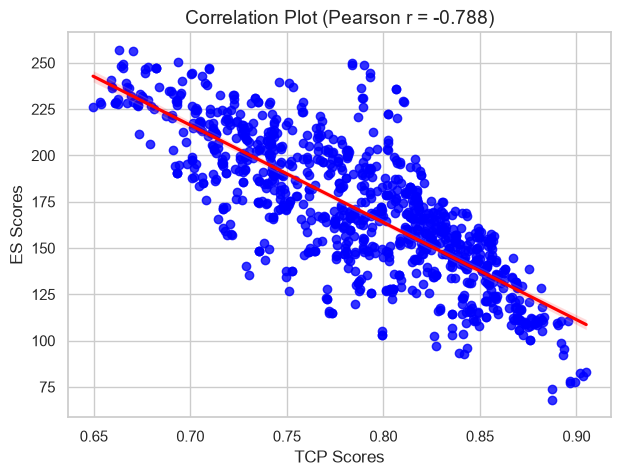

In [98]:
corr_coef, p_value = pearsonr(tcp_scores, es_scores)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

sns.regplot(x=tcp_scores, y=es_scores, scatter_kws={"color": "blue"}, line_kws={"color": "red"}, marker="o")

plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
plt.xlabel("TCP Scores")
plt.ylabel("ES Scores")

plt.show()

## PARTITION PLOTTING

plotting most preserved map:
tcp score: 0.905
cut edges: 616
dem seats won: 5/8


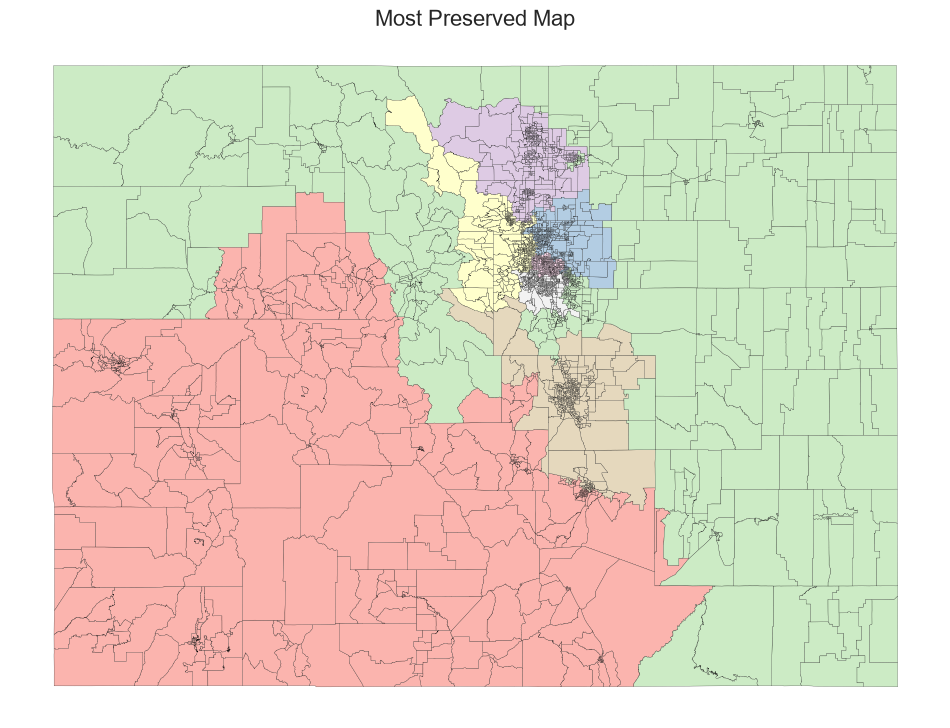

0.784373787601778


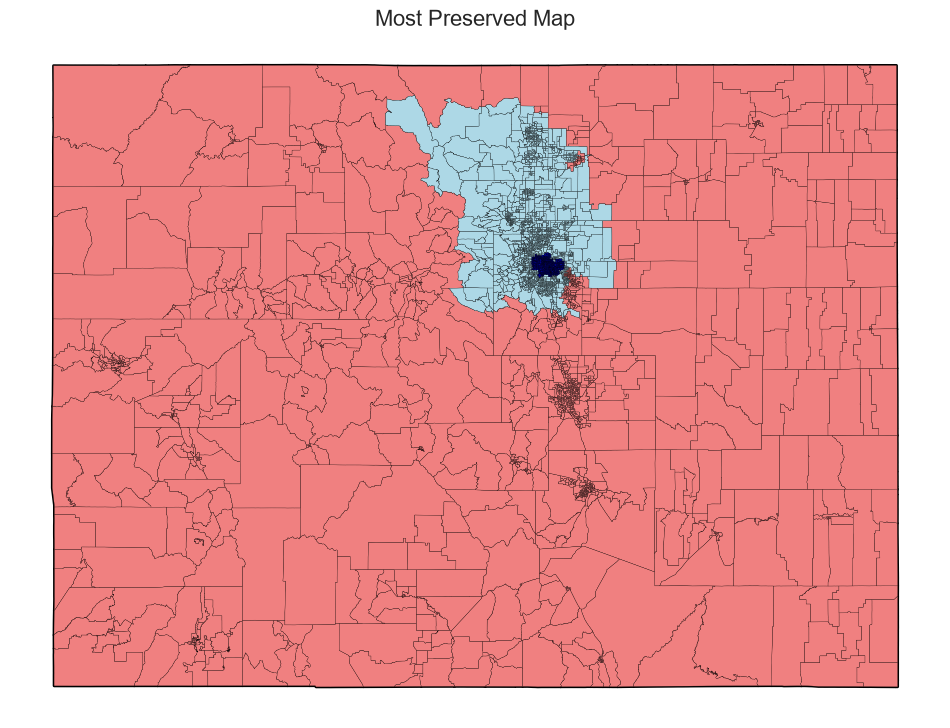

plotting least preserved map:
tcp score: 0.650
cut edges: 695
dem seats won: 5/8


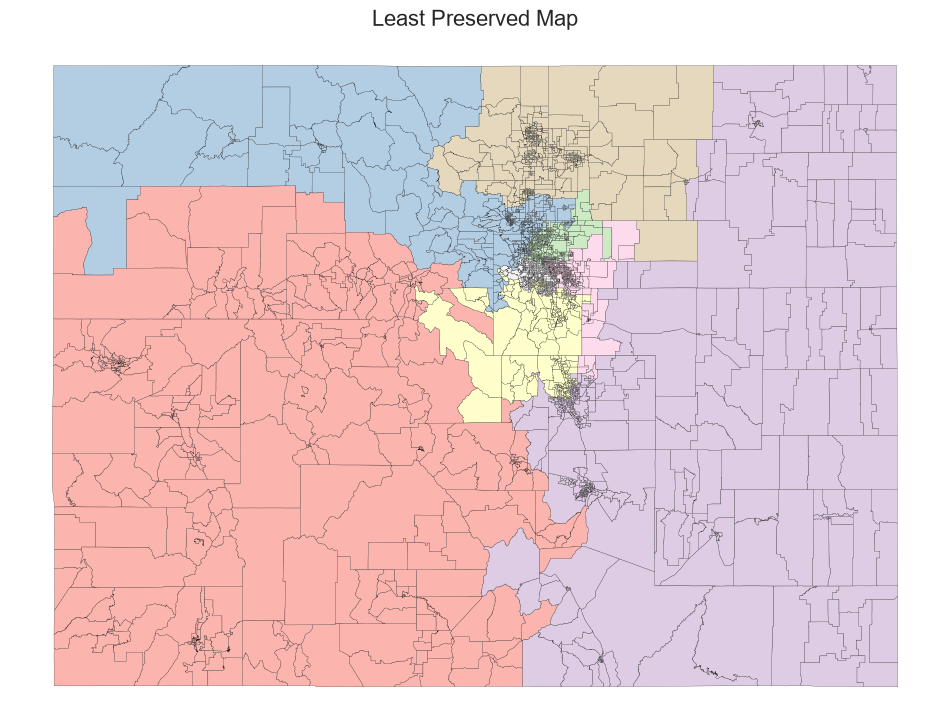

0.6761647805220874


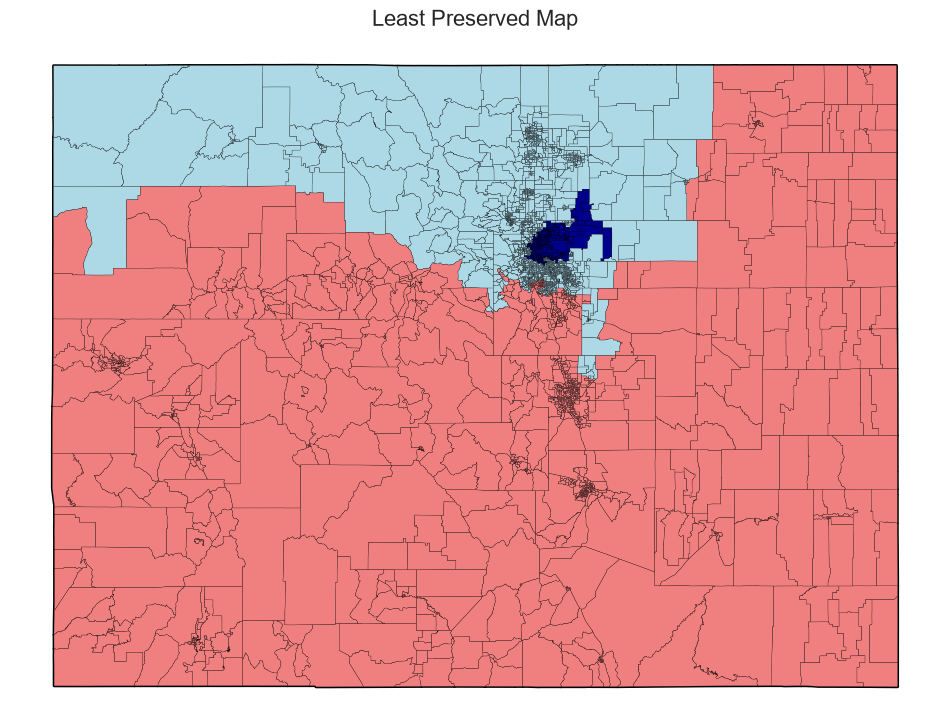

plotting best max representation map:
tcp score: 0.876
cut edges: 665
dem seats won: 6/8


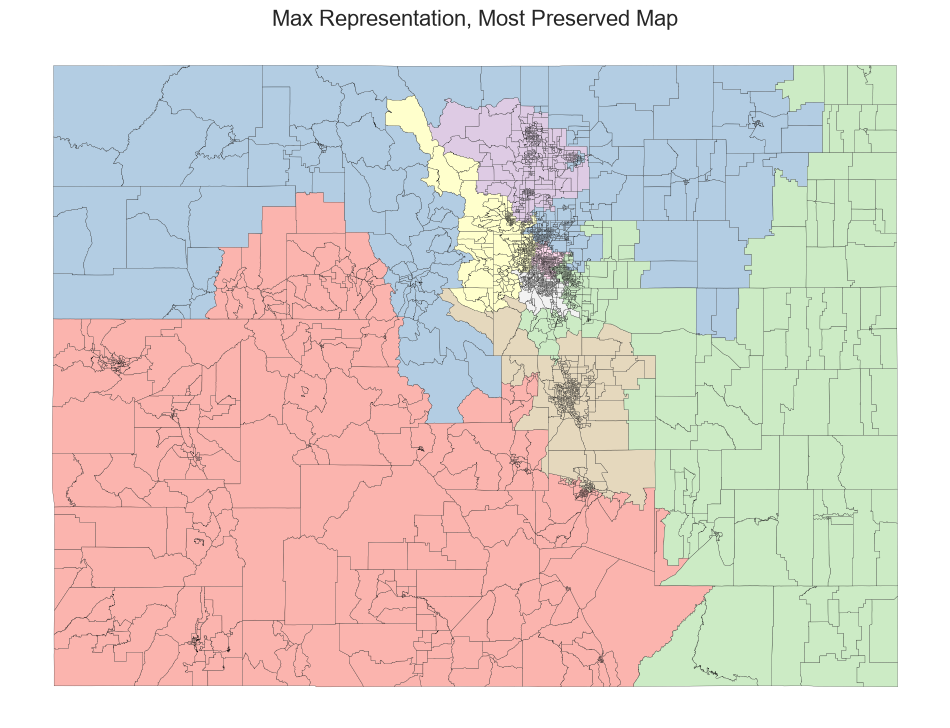

0.7894333023608042


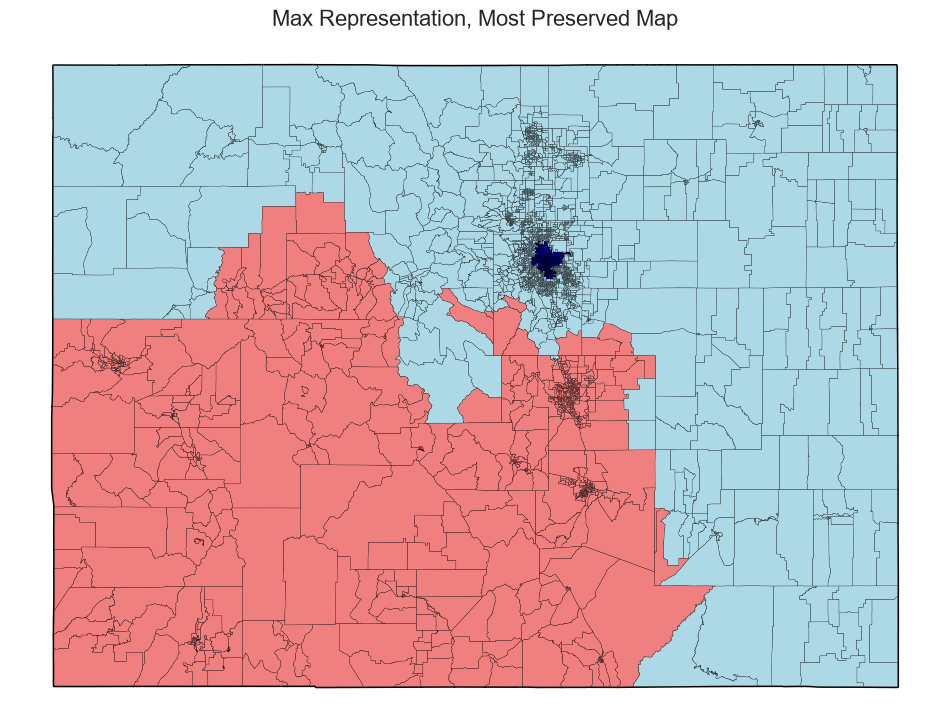

In [95]:

print("plotting most preserved map:")
print(f"tcp score: {best_map['tcp_score']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"dem seats won: {best_map['dem_wins']}/8")
plot_partition(best_map, vtds, cois, 'Most Preserved Map')
plot_partition_party(best_map, vtds, cois, 'Most Preserved Map')


print("plotting least preserved map:")
print(f"tcp score: {worst_map['tcp_score']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"dem seats won: {worst_map['dem_wins']}/8")
plot_partition(worst_map, vtds, cois, 'Least Preserved Map')
plot_partition_party(worst_map, vtds, cois, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"tcp score: {overall_best_map['tcp_score']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"dem seats won: {overall_best_map['dem_wins']}/8")
plot_partition(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')
plot_partition_party(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')



## PLOTLY INTERACTICE MAP

In [96]:
'''
df_2021 = extract_data(enacted_2021)

community_scores_2021 = score_communities(df_2021)
worst_preserved_2021 = community_scores_2021.sort_values(by='sss_score')

# 2021 map
plot_detailed(
    vtds_gdf=vtds, 
    cois_gdf=cois, 
    community_scores_df=community_scores_2021, 
    district_col='district_2021', 
    title="COLORADO COI Preservation: 2021 Enacted Map")
'''

'\ndf_2021 = extract_data(enacted_2021)\n\ncommunity_scores_2021 = score_communities(df_2021)\nworst_preserved_2021 = community_scores_2021.sort_values(by=\'sss_score\')\n\n# 2021 map\nplot_detailed(\n    vtds_gdf=vtds, \n    cois_gdf=cois, \n    community_scores_df=community_scores_2021, \n    district_col=\'district_2021\', \n    title="COLORADO COI Preservation: 2021 Enacted Map")\n'

## 2021 ENACTED MAP

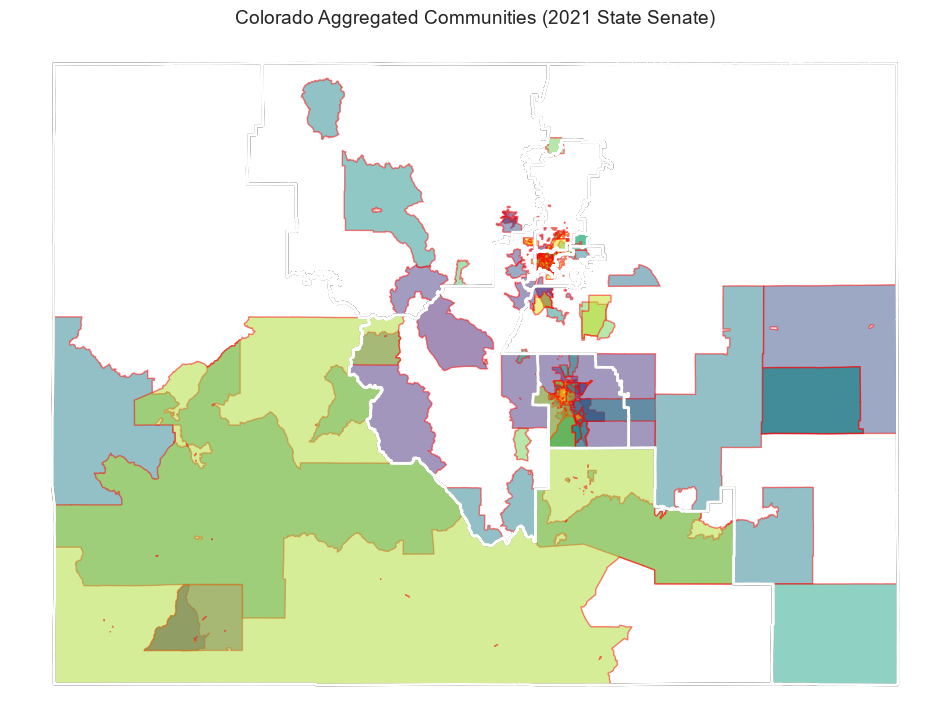

0.7951340039835615


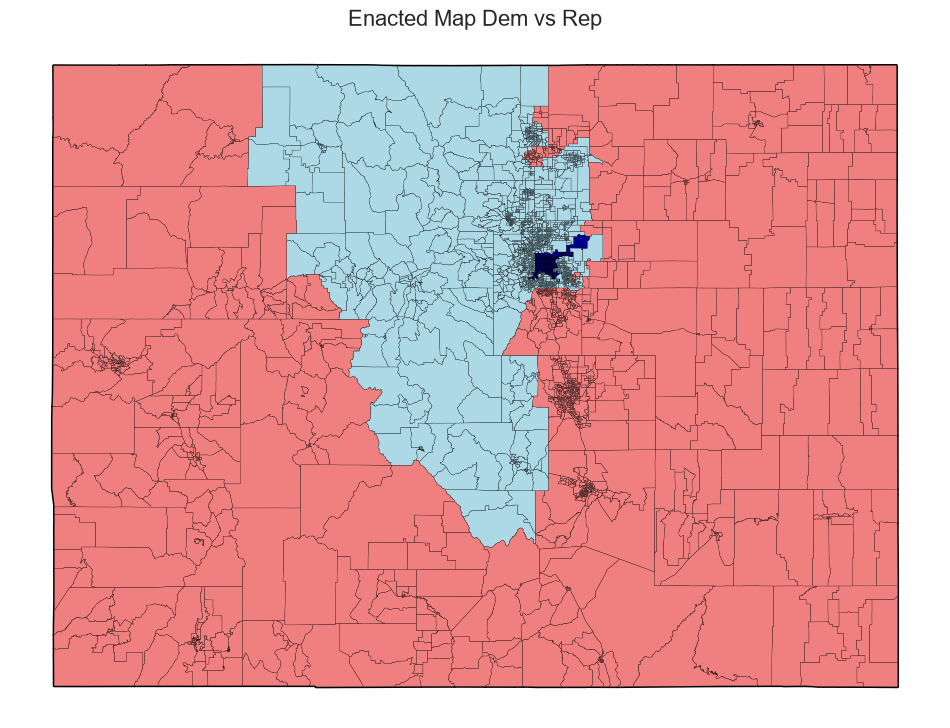

In [97]:
fig, ax = plt.subplots(figsize=(12, 10))

congressional_2021.plot(ax=ax, edgecolor='black', color='white',linewidth=2)
cois.plot(ax=ax, cmap="viridis",edgecolor="red", alpha=0.5)
congressional_2021.plot(ax=ax, facecolor='none', linewidth=2)

ax.set_title("Colorado Aggregated Communities (2021 State Senate)", fontsize=14)
ax.axis("off")
plt.show()

plot_partition_party(enacted_2021, vtds, cois, 'Enacted Map Dem vs Rep')